# 00_raw_eda · 117680 KODEX 철강 (slot 11) — ETF Raw EDA

SSOT: `notebooks/_template/00_etf_raw_eda.ipynb` → `scripts/build_notebooks.py` 로 생성. 이 파일을 직접 고치지 말 것.

In [1]:
TICKER = "117680"
SLOT = 11

In [2]:
import sys, os, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown
warnings.filterwarnings("ignore")
np.random.seed(0)

ROOT = Path.cwd().resolve()
while not (ROOT / "config" / "universe.csv").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("config/universe.csv not found")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src import eda_utils as eu
from src.style import setup_notebook, banner, kpis
setup_notebook()
LIMITATIONS = [eu.LIMITATION_PRICE]
def cap(sec, st, extra=None):
    display(Markdown(eu.caption(sec, st, extra)))

## 00 Identity / Domain Card

In [3]:
U = eu.read_universe(ROOT)
row = U.loc[U["ticker"] == TICKER].iloc[0].to_dict()
banner(f"{TICKER} · {row.get('name','')}", f"UNIVERSE_STATUS={row.get('universe_status','PROVISIONAL') or 'PROVISIONAL'} — 공식 list 입수 시 교체")
display(pd.DataFrame([row]).T.rename(columns={0: "value"}))
KEYF = ["benchmark", "benchmark_proxy_ticker", "currency_hedge", "replication", "trading_hours_note", "structural_notes", "confidence"]
display(pd.DataFrame({"field": KEYF, "value": [row.get(k, "(missing column)") for k in KEYF]}))
print("price policy:", eu.PRICE_POLICY_UNADJ)

,value
slot,11
ticker,117680
name,KODEX 철강
provider_brand,KODEX (삼성자산운용)
listing_date,2009-10
listing_date_source,"domain knowledge [ANA, uncertain]; FDR first r..."
data_start,2019-01-02
asset_scope,domestic_equity
category,sector
benchmark,KRX 철강 (추정)


,field,value
0,benchmark,KRX 철강 (추정)
1,benchmark_proxy_ticker,069500
2,currency_hedge,n/a (KRW)
3,replication,physical
4,trading_hours_note,KRX same-session
5,structural_notes,"[OBS] Category=2, MarCap 303억 소형 → 거래량 0/저유동성 ..."
6,confidence,low


price policy: FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으로 추정(069500/KS200 누적비 1.155 ≈ TR 1.163), O/H/L 조정 일관성 미보장 — KNOWN_LIMITATION


### 00 · 이 ETF 는 무엇인가 (ETF-specific)
- **KODEX 철강 (117680)** · domestic_equity / sector · 추종 KRX 철강 (추정) · 레버리지 none · 환헤지 n/a (KRW) · 복제 physical.
- 거래시간: KRX same-session.
- 비교 기준 ETF(benchmark proxy): 069500.
- UNIVERSE_STATUS=PROVISIONAL · 수익률은 조정가격 수익률(추정, DEC-3).

### ETF-specific reading (A card @69b99d3)
**정체성**

- [OBS] domestic_equity / sector / 기준지수 KRX 철강(추정) / peer_group KR_sector / 환헤지 n/a / physical. taxonomy confidence=low.
- [OBS] **low_liquidity flag**(DEC-4): med_volume 58,264주(분석 대상 5개 중 2번째로 적음), MarCap 303억 소형 → 괴리·호가 공백 가능 [ANA].

## 01 Raw Data Audit

In [4]:
raw, PROV = eu.load_raw(eu.raw_path(TICKER))
print("price_policy:", PROV["price_policy"])
display(pd.DataFrame([{k: v for k, v in PROV.items() if k != "duplicate_dates"}]).T.rename(columns={0: "value"}))
display(eu.quality_summary(raw))
OHLC_BAD = eu.ohlc_violations(raw); GAPS = eu.date_gaps(raw, 5)
print("OHLC violations:", len(OHLC_BAD)); display(OHLC_BAD.head(10))
print("date gaps > 5 calendar days:", len(GAPS)); display(GAPS)
x, FLAGS = eu.engineer_basic(raw)
HAS_VOL = FLAGS["has_volume"]
if not HAS_VOL: LIMITATIONS.append("no_volume")
if FLAGS["n_zero_volume_days"] > 0: LIMITATIONS.append("zero_volume_days")
if len(x) < 500: LIMITATIONS.append("short_history")
if PROV["n_duplicate_dates"] > 0: LIMITATIONS.append("duplicate_dates")
START, END, N = x["date"].iloc[0], x["date"].iloc[-1], len(x)
ZERO_VOL_RATIO = FLAGS["n_zero_volume_days"] / N
print("first", START.date(), "last", END.date())

price_policy: FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으로 추정(069500/KS200 누적비 1.155 ≈ TR 1.163), O/H/L 조정 일관성 미보장 — KNOWN_LIMITATION


,value
source_file,/home/sieg/projects-wsl/hongik_univ_26_2/SA/ET...
rows_raw,1903
n_unparseable_dates,0
was_sorted,True
n_duplicate_dates,0
rows_after,1903
price_policy,FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으...
has_adj_close,False
has_volume,True
n_zero_volume_days,0


,column,dtype,n,missing_n,missing_pct,unique_n
0,date,datetime64[us],1903,0,0.0000,1903
1,open,int64,1903,0,0.0000,1403
2,high,int64,1903,0,0.0000,1426
3,low,int64,1903,0,0.0000,1400
4,close,int64,1903,0,0.0000,1424
5,volume,int64,1903,0,0.0000,1886
6,change,float64,1903,0,0.0000,1874
7,price,int64,1903,0,0.0000,1424


OHLC violations: 0


,date,open,high,low,close


date gaps > 5 calendar days: 9


,date,prev_date,gap_days
0,2019-02-07,2019-02-01,6
1,2020-10-05,2020-09-29,6
2,2021-09-23,2021-09-17,6
3,2022-02-03,2022-01-28,6
4,2023-10-04,2023-09-27,7
5,2024-09-19,2024-09-13,6
6,2025-01-31,2025-01-24,7
7,2025-10-10,2025-10-02,8
8,2026-02-19,2026-02-13,6


first 2019-01-02 last 2026-10-02


In [5]:
extra = [f"가격 정책: {PROV['price_policy']}"]
if not HAS_VOL: extra.append("거래량 컬럼이 없거나 전부 0 → 거래량 기반 분석 생략")
cap("01", {"rows_raw": PROV["rows_raw"], "rows_after": PROV["rows_after"], "n_duplicate_dates": PROV["n_duplicate_dates"],
           "n_unparseable_dates": PROV["n_unparseable_dates"], "was_sorted": PROV["was_sorted"], "ohlc_violations": len(OHLC_BAD),
           "n_gaps_gt5d": len(GAPS), "n_zero_volume_days": FLAGS["n_zero_volume_days"], "zero_vol_ratio": ZERO_VOL_RATIO,
           "first": START.date(), "last": END.date()}, extra)

#### 01 · WHAT WE SEE (raw values)
- `rows_raw` = 1903
- `rows_after` = 1903
- `n_duplicate_dates` = 0
- `n_unparseable_dates` = 0
- `was_sorted` = True
- `ohlc_violations` = 0
- `n_gaps_gt5d` = 9
- `n_zero_volume_days` = 0
- `zero_vol_ratio` = 0
- `first` = 2019-01-02
- `last` = 2026-10-02

#### General note · WHY IT MATTERS
행 수·중복·결측·날짜 공백은 이후 모든 rolling 창과 정렬(merge)의 기준이 된다. 감사되지 않은 행은 전처리 단계에서 조용히 왜곡을 만든다.

#### General note · WHAT WE DO NOT KNOW
- 원천(FDR) 이 휴장일 외의 누락을 어떻게 처리하는지는 이 데이터만으로 확인할 수 없다.
- 가격 정책: FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으로 추정(069500/KS200 누적비 1.155 ≈ TR 1.163), O/H/L 조정 일관성 미보장 — KNOWN_LIMITATION

#### General note · NEXT QUESTION
- 감사에서 걸린 행(중복/공백/OHLC 위반)을 전처리에서 제거·보간·flag 중 무엇으로 처리할 것인가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


## 02 Whole-History Visual Scan

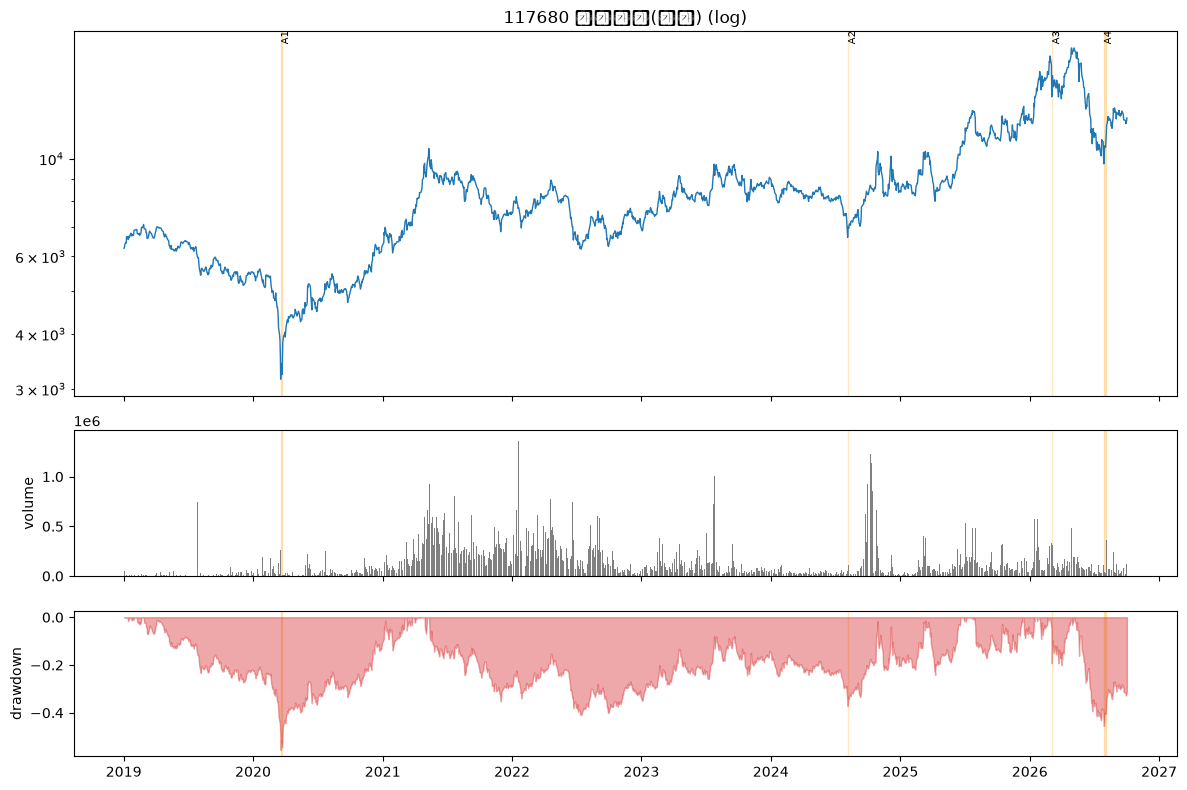

In [6]:
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True, height_ratios=[3, 1.2, 1.2])
ax[0].plot(x["date"], x["price"], lw=1); ax[0].set_yscale("log"); ax[0].set_title(f"{TICKER} 조정가격(추정) (log)")
ANCH = eu.read_event_anchors(ROOT)
for _, a in ANCH.iterrows():
    s0, s1 = pd.to_datetime(a["start"], errors="coerce"), pd.to_datetime(a["end"] or a["start"], errors="coerce")
    if pd.notna(s0):
        for axx in ax: axx.axvspan(s0, s1 if pd.notna(s1) else s0, color="orange", alpha=.25)
        ax[0].text(s0, ax[0].get_ylim()[1], a.get("anchor_id", ""), fontsize=7, va="top", rotation=90)
if HAS_VOL: ax[1].bar(x["date"], x["volume"], width=1.5, color="gray")
else: ax[1].text(0.5, 0.5, "no volume", transform=ax[1].transAxes, ha="center")
ax[1].set_ylabel("volume")
ax[2].fill_between(x["date"], x["drawdown"], 0, color="tab:red", alpha=.4); ax[2].set_ylabel("drawdown")
plt.tight_layout(); plt.show()

In [7]:
cap("02", {"price_first": x["price"].iloc[0], "price_last": x["price"].iloc[-1],
           "price_min": x["price"].min(), "price_max": x["price"].max(), "min_drawdown": x["drawdown"].min(),
           "volume_median": x["volume"].median() if HAS_VOL else "n/a"})

#### 02 · WHAT WE SEE (raw values)
- `price_first` = 6260
- `price_last` = 12370
- `price_min` = 3158
- `price_max` = 17851
- `min_drawdown` = -0.5546
- `volume_median` = 5.826e+04

#### General note · WHY IT MATTERS
전체 이력의 수준·거래량·낙폭을 한 화면에서 보면 구조 변화(regime)나 이상 구간이 있는지, 정규화 창을 어디서 끊어야 할지 판단할 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- 가격 점프가 분배금/분할 때문인지 실제 가격 변동인지 이 데이터만으로 구분할 수 없다.

#### General note · NEXT QUESTION
- 전체 기간을 하나의 정규화 창으로 볼 수 있는가, 아니면 구간을 나눠야 하는가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


## 03 Return Distribution

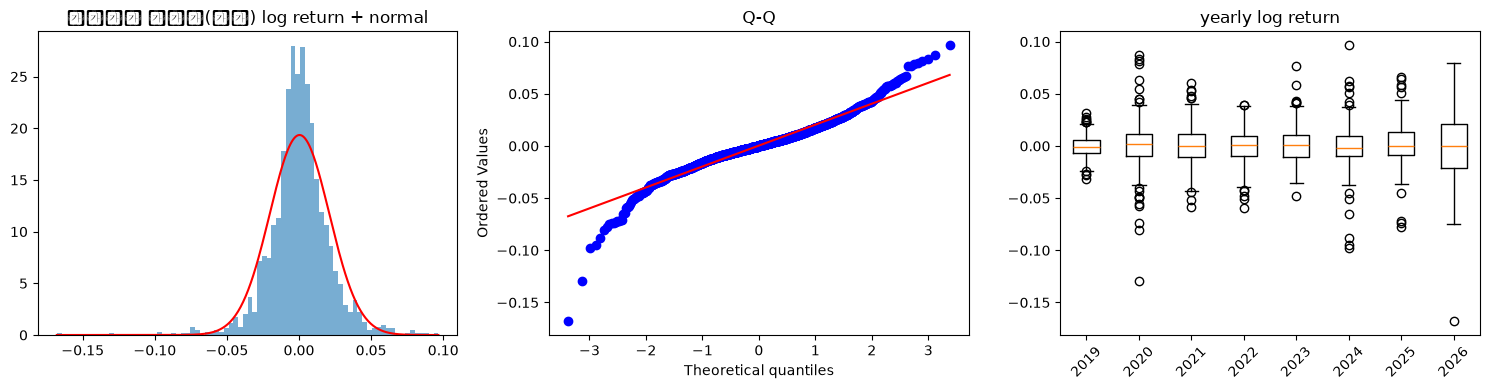

In [8]:
r = x["log_ret"].dropna()
K = {"mean": r.mean(), "std": r.std(), "ann_vol": r.std() * np.sqrt(252), "skew": stats.skew(r),
     "ex_kurt": stats.kurtosis(r), "ex_kurt_trim3": eu.kurt_trim(r, 3), "p01": r.quantile(.01), "p99": r.quantile(.99), "n": len(r)}
kpis([(k, f"{v:.4g}") for k, v in K.items()])
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(r, bins=80, density=True, alpha=.6); g = np.linspace(r.min(), r.max(), 300)
ax[0].plot(g, stats.norm.pdf(g, r.mean(), r.std()), "r-"); ax[0].set_title("조정가격 수익률(추정) log return + normal")
stats.probplot(r, dist="norm", plot=ax[1]); ax[1].set_title("Q-Q")
yr = x.dropna(subset=["log_ret"]).groupby(x["date"].dt.year)["log_ret"]
ax[2].boxplot([v.values for _, v in yr], tick_labels=[str(k) for k, _ in yr]); ax[2].set_title("yearly log return")
ax[2].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

In [9]:
cap("03", K)

#### 03 · WHAT WE SEE (raw values)
- `mean` = 0.0003581
- `std` = 0.02062
- `ann_vol` = 0.3273
- `skew` = -0.3843
- `ex_kurt` = 5.369
- `ex_kurt_trim3` = 2.68
- `p01` = -0.05806
- `p99` = 0.05791
- `n` = 1902

#### General note · WHY IT MATTERS
수익률 분포의 꼬리(첨도·왜도·분위수)는 z-score 같은 정규 가정 기반 정규화가 얼마나 맞지 않는지를 직접 보여준다.

#### General note · WHAT WE DO NOT KNOW
- 분포 모양이 기간에 따라 안정적인지는 단일 전체표본 통계로는 알 수 없다.

#### General note · NEXT QUESTION
- 꼬리 두께를 감안할 때 z-score 대신 robust/분위수 기반 정규화가 필요한가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 03 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **연환산 변동성 32.7%** — 20종 중 6위(높은 순), 백분위 75%, 069500 의 1.15배 (universe 중앙값 28.4%).
- **초과첨도(full) 5.4** — 20종 중 16위(높은 순), 백분위 25%, 069500 의 0.28배 (universe 중앙값 10.5).
- **초과첨도(상위 |r| 3일 제외) 2.7** — 20종 중 18위(높은 순), 백분위 15%, 069500 의 0.34배 (universe 중앙값 3.9).
- **왜도 -0.38** — 20종 중 15위(높은 순), 백분위 30% (universe 중앙값 -0.11).
- **일간 로그수익률 1% 분위 -5.81%** — 20종 중 7위(낮은(더 극단) 순), 백분위 70%, 069500 의 0.97배 (universe 중앙값 -5.18%).
- **일간 로그수익률 99% 분위 +5.79%** — 20종 중 7위(높은 순), 백분위 70%, 069500 의 1.10배 (universe 중앙값 +5.15%).

- DQ 각주: reports/dq_flags.csv 에 이 ETF 의 flag 없음.

### ETF-specific reading (A card @69b99d3)
**평소 움직임**

- [OBS] ann_vol 32.7% / exw 32.4% (5개 중 최고); skew −0.38 / exw −0.40; kurt full 5.37 · trim3 2.68 · exw 5.60.
- [OBS] q01 −5.81% / q99 +5.79%; |r| q95 4.19% / q99 7.24%.
- [OBS] 연도별 ann vol: 2019 17.0% → 2020 37.6% → 2021~23 27~31% → 2024·25 32.9/32.5% → **2026 52.1%** (최고).
- [ANA] 2019 대비 2026 변동성이 3배 — 2026년은 이 ETF에 '다른 체제'.

### 03b Core stats — full / by year / 2026-07-20~08-10 제외 / DQ 포함 vs 제외

In [10]:
SV, DQ_NOTE = eu.stats_variants(x, ROOT, TICKER)
display(SV); print("DQ:", DQ_NOTE)
if DQ_NOTE != "no_dq_flags": LIMITATIONS.append("dq_flagged_dates")  # 해당일 포함/제외 병기됨
exk = [i for i in SV.index if i.startswith("excl_")][0]
cap("03", {"full_ann_vol": SV.loc["full", "ann_vol"], "excl_window_ann_vol": SV.loc[exk, "ann_vol"],
           "full_ex_kurt": SV.loc["full", "ex_kurt"], "excl_window_ex_kurt": SV.loc[exk, "ex_kurt"],
           "dq_excluded_ex_kurt": SV.loc["dq_excluded", "ex_kurt"], "dq_note": DQ_NOTE,
           "year_ann_vol_min": SV.filter(like="year_", axis=0)["ann_vol"].min(), "year_ann_vol_max": SV.filter(like="year_", axis=0)["ann_vol"].max()})

,n,ann_vol,ex_kurt,ex_kurt_trim3,p01,p99,max_dd
full,"1,902.0000",0.3273,5.3691,2.6802,-0.0581,0.0579,-0.5546
year_2019,245.0000,0.1697,0.3990,0.1452,-0.0254,0.0252,-0.2723
year_2020,248.0000,0.3764,5.4647,2.7484,-0.0663,0.0804,-0.4383
year_2021,248.0000,0.3072,0.5149,0.1585,-0.0435,0.0502,-0.3526
year_2022,246.0000,0.2697,0.6353,0.1328,-0.0453,0.0376,-0.3030
year_2023,245.0000,0.2769,1.3458,-0.0298,-0.0351,0.0425,-0.1784
year_2024,244.0000,0.3290,6.4160,3.6490,-0.0783,0.0569,-0.2593
year_2025,242.0000,0.3254,2.0622,0.7626,-0.0608,0.0572,-0.2295
year_2026,184.0000,0.5212,2.9794,-0.1006,-0.0731,0.0684,-0.4547
excl_2026-07-20~2026-08-10,"1,886.0000",0.3237,5.5974,2.7619,-0.0577,0.0573,-0.5546


DQ: no_dq_flags


#### 03 · WHAT WE SEE (raw values)
- `full_ann_vol` = 0.3273
- `excl_window_ann_vol` = 0.3237
- `full_ex_kurt` = 5.369
- `excl_window_ex_kurt` = 5.597
- `dq_excluded_ex_kurt` = 5.369
- `dq_note` = no_dq_flags
- `year_ann_vol_min` = 0.1697
- `year_ann_vol_max` = 0.5212

#### General note · WHY IT MATTERS
수익률 분포의 꼬리(첨도·왜도·분위수)는 z-score 같은 정규 가정 기반 정규화가 얼마나 맞지 않는지를 직접 보여준다.

#### General note · WHAT WE DO NOT KNOW
- 분포 모양이 기간에 따라 안정적인지는 단일 전체표본 통계로는 알 수 없다.

#### General note · NEXT QUESTION
- 꼬리 두께를 감안할 때 z-score 대신 robust/분위수 기반 정규화가 필요한가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


## 04 Volatility Dynamics

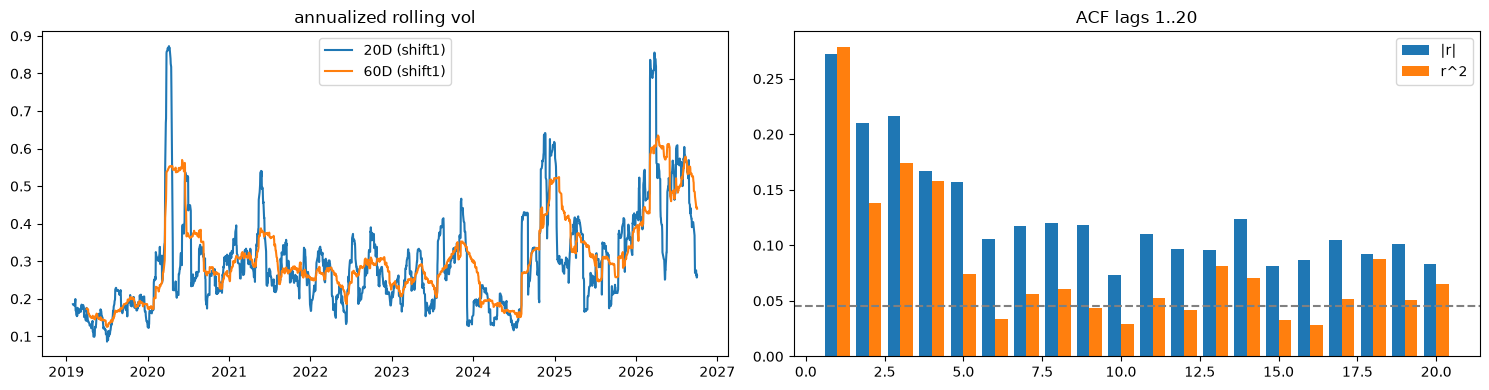

,lag,acf_absret,acf_sqret
0,1,0.2719,0.2787
1,2,0.2100,0.1382
2,3,0.2161,0.1743
3,4,0.1669,0.1583
4,5,0.1573,0.0738
5,6,0.1061,0.0335
6,7,0.1171,0.0559
7,8,0.1197,0.0606
8,9,0.1181,0.0437
9,10,0.0730,0.0296


,lb_stat,lb_pvalue
5,414.3613,0.0000
10,526.3567,0.0000
20,711.8556,0.0000


In [11]:
ACF_ABS = eu.acf(x["abs_ret"], 20); ACF_SQ = eu.acf(x["log_ret"] ** 2, 20)
VOL_OF_VOL = float((x["roll_vol_20"] / x["roll_vol_20"].mean()).std())
from statsmodels.stats.diagnostic import acorr_ljungbox
LB = acorr_ljungbox(x["abs_ret"].dropna(), lags=[5, 10, 20])
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(x["date"], x["roll_vol_20"] * np.sqrt(252), label="20D (shift1)")
ax[0].plot(x["date"], x["roll_vol_60"] * np.sqrt(252), label="60D (shift1)"); ax[0].legend(); ax[0].set_title("annualized rolling vol")
lags = np.arange(1, 21)
ax[1].bar(lags - .2, ACF_ABS, .4, label="|r|"); ax[1].bar(lags + .2, ACF_SQ, .4, label="r^2")
ax[1].axhline(1.96 / np.sqrt(len(x)), ls="--", c="gray"); ax[1].legend(); ax[1].set_title("ACF lags 1..20")
plt.tight_layout(); plt.show()
display(pd.DataFrame({"lag": lags, "acf_absret": ACF_ABS, "acf_sqret": ACF_SQ}).head(10)); display(LB)

In [12]:
cap("04", {"acf_absret_lag1": ACF_ABS[0], "acf_absret_lag5": ACF_ABS[4], "acf_sqret_lag1": ACF_SQ[0],
           "vol_of_vol(cv of roll_vol_20)": VOL_OF_VOL, "ljungbox_absret_lag20_p": LB["lb_pvalue"].iloc[-1],
           "roll_vol_20_ann_median": x["roll_vol_20"].median() * np.sqrt(252)})

#### 04 · WHAT WE SEE (raw values)
- `acf_absret_lag1` = 0.2719
- `acf_absret_lag5` = 0.1573
- `acf_sqret_lag1` = 0.2787
- `vol_of_vol(cv of roll_vol_20)` = 0.4561
- `ljungbox_absret_lag20_p` = 6.856e-138
- `roll_vol_20_ann_median` = 0.2704

#### General note · WHY IT MATTERS
변동성 군집(|r|, r^2 의 자기상관)이 있으면 고정 임계값보다 시간가변 baseline 정규화가 필요하다는 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- 표본이 크면 Ljung-Box 는 작은 자기상관도 유의하게 만든다 — 유의성은 크기의 증거가 아니다.

#### General note · NEXT QUESTION
- baseline 창 길이(20 vs 60)를 무엇으로 고를 것인가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 04 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **|r| lag1 자기상관(변동성 군집) 0.272** — 20종 중 13위(높은 순), 백분위 40%, 069500 의 0.72배 (universe 중앙값 0.302).
- **vol-of-vol 0.456** — 20종 중 16위(높은 순), 백분위 25%, 069500 의 0.60배 (universe 중앙값 0.544).

### ETF-specific reading (A card @69b99d3)
**변동성 구조**

- [OBS] acf_abs1/5/20 = 0.272 / 0.158 / 0.083; lag1 ACF of r = 0.027 (≈0).
- [OBS] 20D rolling vol median 27.0%, p90/p10 = 2.95; vol_ratio_hi_lo(60d, 95%/5%) 3.43.
- [OBS] 60d vol 최고 2026-04-09(63.5%), 최저 2019-07-02(12.5%).

## 05 Trading Activity

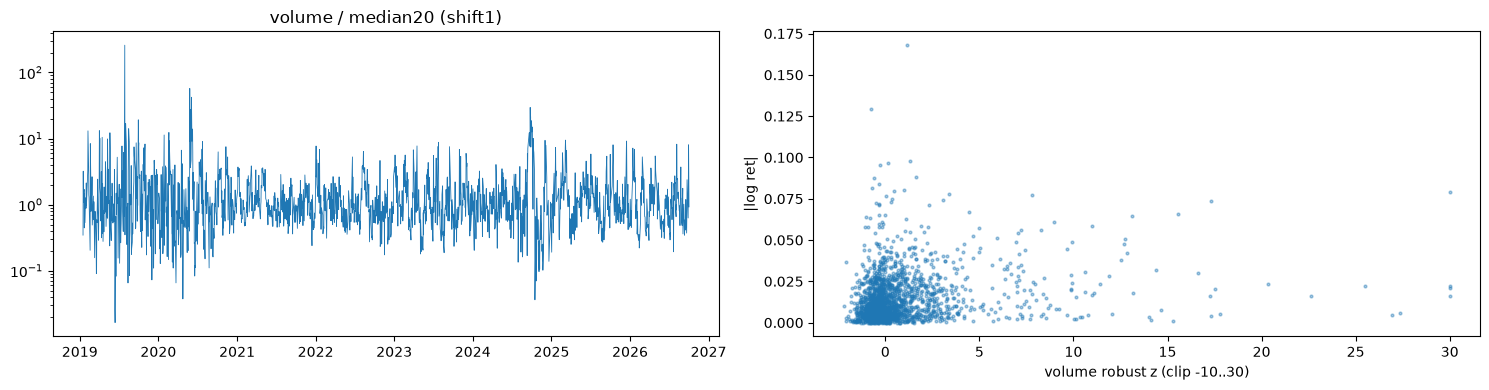

In [13]:
VOLST = {}
if HAS_VOL:
    vz = x["volume_robust_z_20"]
    rho, p = stats.spearmanr(x["abs_ret"], vz, nan_policy="omit")
    ext = x["abs_q95"].fillna(False)
    VOLST = {"spearman_absret_volz": rho, "spearman_p": p, "volz_median_extreme(abs_q95)": vz[ext].median(),
             "volz_median_normal": vz[~ext].median(), "volratio_median_extreme": x["volume_ratio_20"][ext].median(),
             "volratio_median_normal": x["volume_ratio_20"][~ext].median(), "n_mad_zero": FLAGS["n_mad_zero"]}
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    ax[0].plot(x["date"], x["volume_ratio_20"], lw=.6); ax[0].set_yscale("log"); ax[0].set_title("volume / median20 (shift1)")
    ax[1].scatter(vz.clip(-10, 30), x["abs_ret"], s=4, alpha=.4); ax[1].set_xlabel("volume robust z (clip -10..30)"); ax[1].set_ylabel("|log ret|")
    plt.tight_layout(); plt.show()
else:
    print("SKIP: 거래량 없음 (has_volume=False)")
    VOLST = {"skipped": "no_volume"}

In [14]:
cap("05", VOLST, None if HAS_VOL else ["거래량이 없어 이 절 분석을 생략했다."])

#### 05 · WHAT WE SEE (raw values)
- `spearman_absret_volz` = 0.2284
- `spearman_p` = 1.01e-23
- `volz_median_extreme(abs_q95)` = 1.075
- `volz_median_normal` = -0.07756
- `volratio_median_extreme` = 1.89
- `volratio_median_normal` = 0.9465
- `n_mad_zero` = 0

#### General note · WHY IT MATTERS
거래량 baseline(shift(1))과 수익률 크기의 관계는 거래량을 극단 후보의 보조 신호로 쓸 수 있는지에 대한 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- 거래량 급증의 원인(설정/환매, LP 호가, 리밸런싱)은 이 데이터에 없다.

#### General note · NEXT QUESTION
- 거래량 robust z 를 극단 후보의 보조 조건으로 쓸 가치가 있는가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 05 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **거래량 0 일 비율 0.00%** — 20종 중 1위(높은 순), 백분위 100% (universe 중앙값 0.00%).

### ETF-specific reading (A card @69b99d3)
**거래활동**

- [OBS] med_volume 58,264; zero_vol_days 0; corr(|r|, Δlog volume) 0.203.
- [OBS] 상위5 극단일 volume ratio(÷직전20일 median, shift1) ≥2 동반 **1/5** — 2020-03 4일은 0.20~0.34배, 2026-03-04 만 2.40배.
- [ANA] 2020-03 폭락·반등일에 거래량이 오히려 평소의 1/3 — 직전 20일 이미 거래량이 폭증해 분모가 커진 탓일 수 있음(저유동성 소형 ETF).

## 06 Drawdown / Recovery / Persistence

In [15]:
EP = eu.drawdown_episodes(x["price"], x["date"], 5)
i_min = int(x["drawdown"].idxmin()); MAX_DD = float(x["drawdown"].min()); MAX_DD_DATE = x["date"].iloc[i_min].date()
rec = x.index[(x.index > i_min) & (x["drawdown"] >= 0)]
RECOVERY_DAYS = int((x["date"].iloc[rec[0]] - x["date"].iloc[i_min]).days) if len(rec) else None
display(EP)
lp = np.log(x["price"])
fw = {}
for h in (1, 3, 5, 10):
    f = lp.shift(-h) - lp
    fw[h] = {"pos_q95": f[x["pos_q95"]].mean(), "neg_q05": f[x["neg_q05"]].mean(), "all": f.mean()}
FWD = pd.DataFrame(fw).T.rename_axis("h"); display(FWD)
print("※ EDA-only: 겹치는 표본, full-sample 분위수(look-ahead).")

,peak_date,trough_date,depth,recovery_date,recovery_days
0,2019-02-26,2020-03-19,-0.5546,2021-03-05,351.0000
1,2026-04-29,2026-07-29,-0.4547,None,NaN
2,2021-05-11,2022-07-15,-0.4089,2025-06-19,"1,070.0000"
3,2026-02-27,2026-03-31,-0.2006,2026-04-28,28.0000
4,2025-07-23,2025-09-01,-0.1703,2025-12-12,102.0000


,pos_q95,neg_q05,all
h,,,
1,0.0018,-0.0010,0.0004
3,0.0046,-0.0011,0.0010
5,0.0011,-0.0032,0.0017
10,0.0039,-0.0048,0.0034


※ EDA-only: 겹치는 표본, full-sample 분위수(look-ahead).


In [16]:
cap("06", {"max_dd": MAX_DD, "max_dd_date": MAX_DD_DATE, "recovery_days": RECOVERY_DAYS if RECOVERY_DAYS is not None else "not recovered",
           "fwd5_after_pos_q95": FWD.loc[5, "pos_q95"], "fwd5_after_neg_q05": FWD.loc[5, "neg_q05"], "fwd5_all": FWD.loc[5, "all"]})

#### 06 · WHAT WE SEE (raw values)
- `max_dd` = -0.5546
- `max_dd_date` = 2020-03-19
- `recovery_days` = 351
- `fwd5_after_pos_q95` = 0.001142
- `fwd5_after_neg_q05` = -0.003228
- `fwd5_all` = 0.001706

#### General note · WHY IT MATTERS
낙폭 깊이·회복 기간·극단일 이후 forward return 은 이벤트 창 길이와 사후 관측 구간 설계의 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- forward return 은 겹치는 표본(overlapping)이라 독립 관측 수가 실제보다 적다. 인과가 아니다.

#### General note · NEXT QUESTION
- 극단일 이후 며칠까지를 이벤트 창으로 볼 것인가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 06 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **최대 낙폭 -55.5%** — 20종 중 6위(낮은(더 극단) 순), 백분위 75%, 069500 의 1.36배 (universe 중앙값 -47.5%).
- **최대 낙폭 회복일수 351** — 12종 중 8위(높은 순), 백분위 25% (universe 중앙값 377).

### ETF-specific reading (A card @69b99d3)
**언제 이상해지는가**

- [OBS] max_dd −55.5%: peak 2019-02-26 → trough 2020-03-19 → recovered 2021-03-05 (trough→회복 236 거래일). 현재(2026-10-02) dd −30.7% (미회복 구간 진행 중).

## 07 Candidate Extreme Windows

최종 label/threshold 아님. z 후보는 shift(1) baseline, q 후보는 full-sample(look-ahead).

,definition,n_days
0,pos_z2,76
1,neg_z2,67
2,abs_z2,143
3,pos_z2_5,38
4,neg_z2_5,35
5,abs_z2_5,73
6,pos_z3,16
7,neg_z3,19
8,abs_z3,35
9,pos_q95,96


,abs_z2,abs_z2_5,abs_z3,abs_q95
abs_z2,1.0000,0.5105,0.2448,0.3352
abs_z2_5,0.5105,1.0000,0.4795,0.3413
abs_z3,0.2448,0.4795,1.0000,0.2843
abs_q95,0.3352,0.3413,0.2843,1.0000


,date,price,log_ret,ret_z20,roll_vol_20
1379,2024-08-05,6626,-0.0976,-8.4404,0.0116
1430,2024-10-24,9575,0.0966,8.0414,0.0120
1618,2025-08-01,11462,-0.0779,-5.8509,0.0133
299,2020-03-19,3158,-0.1290,-5.2366,0.0246
1758,2026-03-04,13824,-0.1679,-5.1799,0.0324
849,2022-06-13,7650,-0.0422,-4.8188,0.0088
1597,2025-07-03,11732,0.0657,4.5435,0.0145
262,2020-01-28,5229,-0.0485,-4.4893,0.0108
349,2020-06-03,5134,0.0788,4.3180,0.0182
1126,2023-07-24,9373,0.0582,4.1872,0.0139


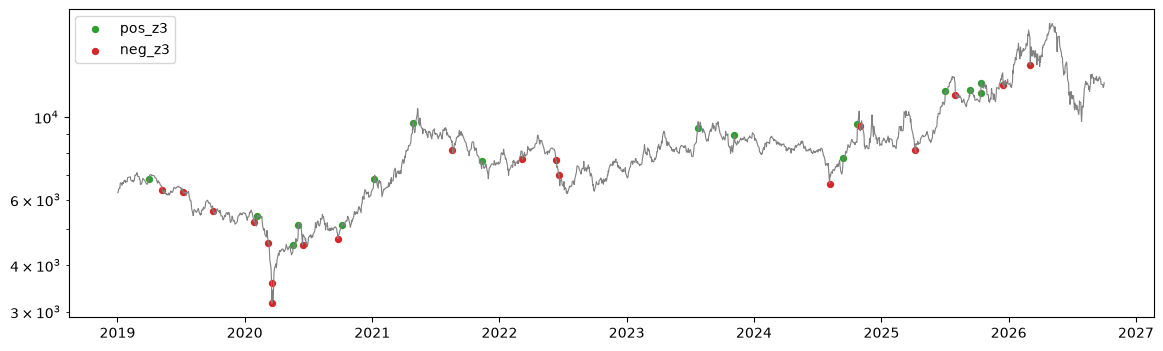

In [17]:
DEFS = [c for c in x.columns if c.startswith(("pos_z", "neg_z", "abs_z")) or c in ("pos_q95", "neg_q05", "abs_q95")]
CNT = pd.DataFrame({"definition": DEFS, "n_days": [int(x[c].sum()) for c in DEFS]}); display(CNT)
absdefs = ["abs_z2", "abs_z2_5", "abs_z3", "abs_q95"]
JAC = pd.DataFrame([[eu.jaccard(x[a], x[b]) for b in absdefs] for a in absdefs], index=absdefs, columns=absdefs); display(JAC)
TOP = x.loc[x["ret_z20"].abs().nlargest(10).index, ["date", "price", "log_ret", "ret_z20", "roll_vol_20"]]; display(TOP)
fig, ax = plt.subplots(figsize=(14, 4)); ax.plot(x["date"], x["price"], lw=.8, c="gray"); ax.set_yscale("log")
ax.scatter(x["date"][x["pos_z3"]], x["price"][x["pos_z3"]], c="tab:green", s=18, label="pos_z3")
ax.scatter(x["date"][x["neg_z3"]], x["price"][x["neg_z3"]], c="tab:red", s=18, label="neg_z3"); ax.legend(); plt.show()
N_POS3, N_NEG3, N_ABS3 = int(x["pos_z3"].sum()), int(x["neg_z3"].sum()), int(x["abs_z3"].sum())

### 07b 정의별 극단일 표 (① abs% q95 ② shift(1) robust z w60 k3 ③ percentile q01/q99)

In [18]:
XDEF, XSC = eu.extreme_definitions(x)
for nm, msk in XDEF.items():
    t = x.loc[msk, ["date", "ret_1d", "log_ret"]].assign(score=XSC[nm][msk])
    print(f"[{nm}] n_days={int(msk.sum())}"); display(t.nlargest(10, "score"))
ks = list(XDEF)
JAC3 = {f"{ks[i]}~{ks[j]}": eu.jaccard(XDEF[ks[i]], XDEF[ks[j]]) for i in range(3) for j in range(i + 1, 3)}
print("Jaccard: " + " | ".join(f"{k}={v:.3f}" for k, v in JAC3.items()))

[abs_pct_q95] n_days=96


,date,ret_1d,log_ret,score
1758,2026-03-04,-0.1546,-0.1679,0.1546
299,2020-03-19,-0.1211,-0.1290,0.1211
1430,2024-10-24,0.1015,0.0966,0.1015
1379,2024-08-05,-0.0930,-0.0976,0.0930
302,2020-03-24,0.0912,0.0873,0.0912
1434,2024-10-30,-0.0910,-0.0954,0.0910
303,2020-03-25,0.0873,0.0837,0.0873
300,2020-03-20,0.0852,0.0817,0.0852
1462,2024-12-09,-0.0842,-0.0880,0.0842
1837,2026-06-29,0.0830,0.0798,0.0830


[robust_z_shift1_w60_k3] n_days=52


,date,ret_1d,log_ret,score
299,2020-03-19,-0.1211,-0.1290,8.7528
1379,2024-08-05,-0.0930,-0.0976,8.7371
1758,2026-03-04,-0.1546,-0.1679,6.0820
302,2020-03-24,0.0912,0.0873,5.9996
1434,2024-10-30,-0.0910,-0.0954,5.9310
1618,2025-08-01,-0.0749,-0.0779,5.8075
300,2020-03-20,0.0852,0.0817,5.7029
1597,2025-07-03,0.0679,0.0657,5.6465
303,2020-03-25,0.0873,0.0837,5.6200
1430,2024-10-24,0.1015,0.0966,5.5647


[pctile_q01_q99] n_days=40


,date,ret_1d,log_ret,score
1758,2026-03-04,-0.1546,-0.1679,0.1546
299,2020-03-19,-0.1211,-0.1290,0.1211
1430,2024-10-24,0.1015,0.0966,0.1015
1379,2024-08-05,-0.0930,-0.0976,0.0930
302,2020-03-24,0.0912,0.0873,0.0912
1434,2024-10-30,-0.0910,-0.0954,0.0910
303,2020-03-25,0.0873,0.0837,0.0873
300,2020-03-20,0.0852,0.0817,0.0852
1462,2024-12-09,-0.0842,-0.0880,0.0842
1837,2026-06-29,0.0830,0.0798,0.0830


Jaccard: abs_pct_q95~robust_z_shift1_w60_k3=0.333 | abs_pct_q95~pctile_q01_q99=0.417 | robust_z_shift1_w60_k3~pctile_q01_q99=0.353


In [19]:
cap("07", {"n_pos_z3": N_POS3, "n_neg_z3": N_NEG3, "n_abs_z3": N_ABS3, "n_abs_z2": int(x["abs_z2"].sum()),
           "n_abs_q95": int(x["abs_q95"].sum()), "jaccard_abs_z3_vs_abs_q95": JAC.loc["abs_z3", "abs_q95"],
           "jaccard_abs_z2_vs_abs_z3": JAC.loc["abs_z2", "abs_z3"], **{f"n_{k}": int(v.sum()) for k, v in XDEF.items()}, **{f"jac_{k}": v for k, v in JAC3.items()}, "max_abs_ret_z20": x["ret_z20"].abs().max()})

#### 07 · WHAT WE SEE (raw values)
- `n_pos_z3` = 16
- `n_neg_z3` = 19
- `n_abs_z3` = 35
- `n_abs_z2` = 143
- `n_abs_q95` = 96
- `jaccard_abs_z3_vs_abs_q95` = 0.2843
- `jaccard_abs_z2_vs_abs_z3` = 0.2448
- `n_abs_pct_q95` = 96
- `n_robust_z_shift1_w60_k3` = 52
- `n_pctile_q01_q99` = 40
- `jac_abs_pct_q95~robust_z_shift1_w60_k3` = 0.3333
- `jac_abs_pct_q95~pctile_q01_q99` = 0.4167
- `jac_robust_z_shift1_w60_k3~pctile_q01_q99` = 0.3529
- `max_abs_ret_z20` = 8.44

#### General note · WHY IT MATTERS
후보 정의마다 선택되는 날이 얼마나 겹치는지는 극단 정의가 정의 선택에 얼마나 민감한지를 보여준다 (최종 정의는 여기서 정하지 않는다).

#### General note · WHAT WE DO NOT KNOW
- q95/q05 후보는 전체표본 분위수(look-ahead) 이므로 실시간 탐지에는 쓸 수 없다.

#### General note · NEXT QUESTION
- 후보 정의 간 불일치가 큰 날들은 어떤 공통 특성을 갖는가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 07 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **|z|≥3 후보일(shift(1) 20D vol 기준) 35** — 20종 중 7위(높은 순), 백분위 70%, 069500 의 1.06배 (universe 중앙값 34).
- **z≥+3 후보일 16** — 20종 중 7위(높은 순), 백분위 70%, 069500 의 1.33배 (universe 중앙값 14).
- **z≤−3 후보일 19** — 20종 중 10위(높은 순), 백분위 55%, 069500 의 0.90배 (universe 중앙값 19).

- DQ 각주: reports/dq_flags.csv 에 이 ETF 의 flag 없음.

### ETF-specific reading (A card @69b99d3)
**언제 이상해지는가**

- [OBS] 상위 5 |robust-z|: 2020-03-19 −12.9% (rz −13.5, univ median −8.0%, fwd5 +20.6%) · 2020-03-24 +8.7% (9.5, +6.6%) · 2020-03-25 +8.4% (9.0, +4.3%) · 2026-03-04 −16.8% (−9.0, −11.5%, fwd5 +8.3%) · 2020-03-20 +8.2% (8.9, +7.3%) → **5/5 공통 충격**(univ median 같은 방향).
- [OBS] 고유 충격(specific_shock_days: 해당 ETF trailing-std z>3 & 나머지 median|z|<1) 6일, 이 중 2024-10-24 +9.7%(z 6.2), 2024-10-30 −9.5%(z −5.6) — 같은날 univ median −0.6/−0.5%.
- [OBS] 극단일 정의: |robust-z|>3 28일(참고: trailing 60d std shift1 기준 |z|>3 28일, >4 8일). common_shock_days 55일 중 47일 참여.
- [OBS] 2026-07-20~08-10 창 최대 |r| 7.1% (069500 21.7% 대비 작음) → exw 수치 변화 미미.

## 08 Benchmark / Peer Relationship

benchmark (index name): KRX 철강 (추정) | proxy ticker: 069500


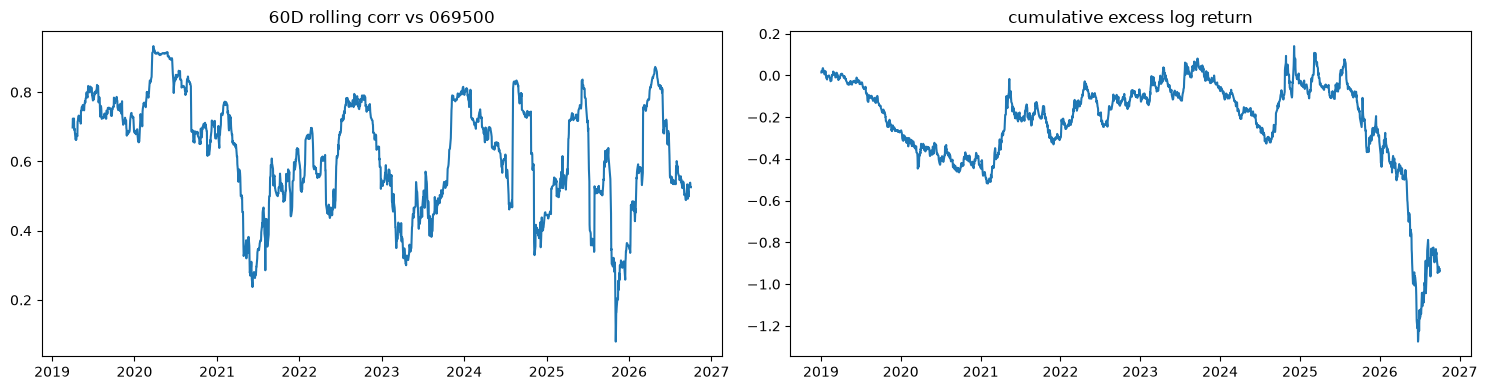

,117680,091230,091170,091180,305540,143860,161510
117680,1.0000,0.4826,0.5277,0.5582,0.6191,0.4536,0.6573
091230,0.4826,1.0000,0.3629,0.5133,0.5120,0.4678,0.4708
091170,0.5277,0.3629,1.0000,0.4995,0.3529,0.3608,0.8619
091180,0.5582,0.5133,0.4995,1.0000,0.5013,0.3958,0.6350
305540,0.6191,0.5120,0.3529,0.5013,1.0000,0.4665,0.4511
143860,0.4536,0.4678,0.3608,0.3958,0.4665,1.0000,0.4362
161510,0.6573,0.4708,0.8619,0.6350,0.4511,0.4362,1.0000


In [20]:
BETA = CORR = None; BST = {}
bm = row.get("benchmark_proxy_ticker", "")
print("benchmark (index name):", row.get("benchmark", ""), "| proxy ticker:", bm or "(none)")
if bm and bm != TICKER and eu.raw_path(bm).exists():
    b, _ = eu.load_raw(eu.raw_path(bm)); b, _ = eu.engineer_basic(b)
    m = x[["date", "log_ret"]].merge(b[["date", "log_ret"]], on="date", how="outer", suffixes=("", "_bm"), indicator=True)
    n_unm = int((m["_merge"] != "both").sum()); mm = m[m["_merge"] == "both"].dropna(subset=["log_ret", "log_ret_bm"]).sort_values("date")
    BETA = float(np.cov(mm["log_ret"], mm["log_ret_bm"])[0, 1] / mm["log_ret_bm"].var()); CORR = float(mm["log_ret"].corr(mm["log_ret_bm"]))
    rc = mm["log_ret"].rolling(60).corr(mm["log_ret_bm"])
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    ax[0].plot(mm["date"], rc); ax[0].set_title(f"60D rolling corr vs {bm}")
    ax[1].plot(mm["date"], (mm["log_ret"] - mm["log_ret_bm"]).cumsum()); ax[1].set_title("cumulative excess log return")
    plt.tight_layout(); plt.show()
    BST = {"benchmark": bm, "n_unmatched_dates": n_unm, "n_matched": len(mm), "beta": BETA, "corr": CORR, "rolling_corr60_min": rc.min()}
else:
    reason = "benchmark_proxy_ticker 미지정" if not bm else ("self" if bm == TICKER else "benchmark raw 없음")
    print("SKIP benchmark:", reason); BST = {"benchmark_skip": reason}
    if bm and bm != TICKER: LIMITATIONS.append("benchmark_missing")  # proxy 미지정(기준 자체·비주식)은 설계상 정상
pg = row.get("peer_group", "")
peers = [t for t in U.loc[(U["peer_group"] == pg) & (U["ticker"] != TICKER), "ticker"] if pg and eu.raw_path(t).exists()]
if peers:
    rets = {TICKER: x.set_index("date")["log_ret"]}
    for t in peers:
        d, _ = eu.load_raw(eu.raw_path(t)); d, _ = eu.engineer_basic(d); rets[t] = d.set_index("date")["log_ret"]
    PC = pd.DataFrame(rets).corr(); display(PC); BST["n_peers"] = len(peers); BST["peer_corr_mean"] = PC[TICKER].drop(TICKER).mean()
else:
    print("peer 없음 (peer_group=", pg, ")")

In [21]:
cap("08", BST)

#### 08 · WHAT WE SEE (raw values)
- `benchmark` = 069500
- `n_unmatched_dates` = 0
- `n_matched` = 1902
- `beta` = 0.6831
- `corr` = 0.594
- `rolling_corr60_min` = 0.07963
- `n_peers` = 6
- `peer_corr_mean` = 0.5498

#### General note · WHY IT MATTERS
벤치마크·peer 와의 동조성은 개별 ETF 신호와 시장 공통 신호를 분리(초과수익 정규화)해야 하는지에 대한 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- benchmark 는 universe 내 대리 ticker 이며 공식 추종지수 자체가 아닐 수 있다.

#### General note · NEXT QUESTION
- 극단 후보를 원수익률이 아니라 benchmark 초과수익으로 정의해야 하는가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 08 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **benchmark proxy 와 상관 0.594** — 17종 중 10위(높은 순), 백분위 40%, 069500 의 0.59배 (universe 중앙값 0.655).
- **benchmark proxy 대비 beta 0.68** — 17종 중 11위(높은 순), 백분위 35%, 069500 의 0.68배 (universe 중앙값 0.74).

### ETF-specific reading (A card @69b99d3)
**peer 와 다른 점**

- [OBS] 상위 spearman: 161510 0.581, 122630 0.559, 102110 0.557 / 하위: 114800 −0.556, 261240 −0.350, 148070 −0.002.

## 09 Multivariate Structure (diagnostic)

,pc,explained_ratio
0,PC1,0.8607
1,PC2,0.0651
2,PC3,0.0315
3,PC4,0.0208


pc,PC1,PC2,PC3,PC4
log_ret,0.0062,-0.1066,0.9750,-0.1070
abs_ret,0.0148,0.5438,0.0777,-0.3166
roll_vol_20,-0.0085,0.3422,0.1750,0.8921
drawdown,0.0045,-0.0279,0.1123,-0.2297
range_pct,0.0179,0.7581,0.0065,-0.1987
volume_robust_z_20,0.9997,-0.0179,-0.0063,0.0175


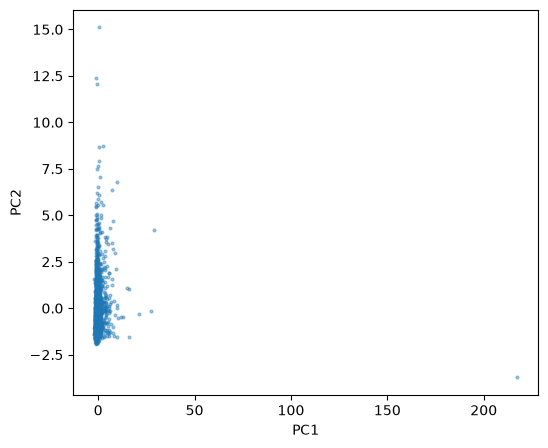

In [22]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
feats = ["log_ret", "abs_ret", "roll_vol_20", "drawdown"] + (["range_pct"] if "range_pct" in x else []) + (["volume_robust_z_20"] if HAS_VOL else [])
F = x[feats].replace([np.inf, -np.inf], np.nan).dropna()
Z = RobustScaler().fit_transform(F); pca = PCA(n_components=min(len(feats), 4), random_state=0).fit(Z)
EVR = pd.DataFrame({"pc": [f"PC{i+1}" for i in range(pca.n_components_)], "explained_ratio": pca.explained_variance_ratio_}); display(EVR)
LOAD = pd.DataFrame(pca.components_.T, index=feats, columns=EVR["pc"]); display(LOAD)
S = pca.transform(Z); plt.figure(figsize=(6, 5)); plt.scatter(S[:, 0], S[:, 1], s=4, alpha=.4); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()
PC1 = float(pca.explained_variance_ratio_[0])

In [23]:
cap("09", {"n_rows_used": len(F), "features": ", ".join(feats), "pc1_ratio": PC1, "pc2_ratio": float(pca.explained_variance_ratio_[1]),
           "pc1_top_loading": LOAD["PC1"].abs().idxmax()})

#### 09 · WHAT WE SEE (raw values)
- `n_rows_used` = 1882
- `features` = log_ret, abs_ret, roll_vol_20, drawdown, range_pct, volume_robust_z_20
- `pc1_ratio` = 0.8607
- `pc2_ratio` = 0.0651
- `pc1_top_loading` = volume_robust_z_20

#### General note · WHY IT MATTERS
여러 feature 가 소수의 축으로 요약되는지는 다변량 정규화·차원 축소가 필요한지에 대한 진단이다.

#### General note · WHAT WE DO NOT KNOW
- PCA 는 선형·전체표본 진단이며, 축의 의미를 확정하지 않는다.

#### General note · NEXT QUESTION
- PC1 이 주로 변동성 축인가, 방향 축인가 — 이것이 ETF 간에 일관적인가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 09 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **PCA PC1 설명비율 86.1%** — 20종 중 1위(높은 순), 백분위 100%, 069500 의 1.59배 (universe 중앙값 50.2%).

## 10 Questions Discovered (SEED only — ACCEPTED/REJECTED 금지)

In [24]:
Q = []
def seed(cond, scope, stmt, ev):
    if cond: Q.append({"id": f"{TICKER}-Q{len(Q)+1:02d}", "scope": scope, "statement": stmt, "status": "SEED", "evidence": ev})
seed(K["ex_kurt"] > 5 and K["ex_kurt_trim3"] > 5, "distribution", "꼬리가 두꺼워 정규 가정 z 정규화가 부적합할 수 있다", f"ex_kurt={K['ex_kurt']:.2f}, trim3={K['ex_kurt_trim3']:.2f}")
seed(ZERO_VOL_RATIO > .01, "volume", "거래량 0 일이 많아 거래량 baseline 이 불안정할 수 있다", f"zero_vol_ratio={ZERO_VOL_RATIO:.3f}")
seed(MAX_DD < -.30, "drawdown", "깊은 낙폭 구간이 정규화 창을 지배할 수 있다", f"max_dd={MAX_DD:.3f}")
seed(abs(ACF_ABS[0]) > .2, "volatility", "변동성 군집이 강해 시간가변 baseline 이 필요할 수 있다", f"acf_absret_lag1={ACF_ABS[0]:.3f}")
seed(not HAS_VOL, "volume", "거래량 부재 — 거래량 기반 후보 정의 불가", "has_volume=False")
seed(CORR is not None and CORR > .9, "benchmark", "benchmark 와 거의 동조 — 초과수익 기준 후보 정의 검토", f"corr={CORR}")
QT = pd.DataFrame(Q, columns=["id", "scope", "statement", "status", "evidence"]); display(QT)

,id,scope,statement,status,evidence
0,117680-Q01,drawdown,깊은 낙폭 구간이 정규화 창을 지배할 수 있다,SEED,max_dd=-0.555
1,117680-Q02,volatility,변동성 군집이 강해 시간가변 baseline 이 필요할 수 있다,SEED,acf_absret_lag1=0.272


## 11 Observation → Implication → Next Question

In [25]:
SUM = pd.DataFrame([
  ("03", "ann_vol / ex_kurt / ex_kurt_trim3", f"{K['ann_vol']:.3f} / {K['ex_kurt']:.2f} / {K['ex_kurt_trim3']:.2f}", eu.NEXT_Q["03"]),
  ("04", "acf_absret_lag1", f"{ACF_ABS[0]:.3f}", eu.NEXT_Q["04"]),
  ("06", "max_dd (date)", f"{MAX_DD:.3f} ({MAX_DD_DATE})", eu.NEXT_Q["06"]),
  ("07", "n_abs_z3 / n_abs_q95", f"{N_ABS3} / {int(x['abs_q95'].sum())}", eu.NEXT_Q["07"]),
  ("08", "corr / beta vs benchmark", f"{CORR} / {BETA}", eu.NEXT_Q["08"]),
  ("09", "pc1_ratio", f"{PC1:.3f}", eu.NEXT_Q["09"]),
], columns=["section", "observation", "number", "next_question"]); display(SUM)
display(Markdown(eu.PLACEHOLDER))

,section,observation,number,next_question
0,03,ann_vol / ex_kurt / ex_kurt_trim3,0.327 / 5.37 / 2.68,꼬리 두께를 감안할 때 z-score 대신 robust/분위수 기반 정규화가 필요한가?
1,04,acf_absret_lag1,0.272,baseline 창 길이(20 vs 60)를 무엇으로 고를 것인가?
2,06,max_dd (date),-0.555 (2020-03-19),극단일 이후 며칠까지를 이벤트 창으로 볼 것인가?
3,07,n_abs_z3 / n_abs_q95,35 / 96,후보 정의 간 불일치가 큰 날들은 어떤 공통 특성을 갖는가?
4,08,corr / beta vs benchmark,0.5939852427427526 / 0.6830509660770365,극단 후보를 원수익률이 아니라 benchmark 초과수익으로 정의해야 하는가?
5,09,pc1_ratio,0.861,"PC1 이 주로 변동성 축인가, 방향 축인가 — 이것이 ETF 간에 일관적인가?"


> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조

### ETF-specific reading (A card @69b99d3)
**WHAT WE SEE / WHY IT MATTERS / WHAT WE DO NOT KNOW / NEXT QUESTION**

- WHAT WE SEE [OBS]: 5개 중 가장 출렁이는 ETF(연 32.7%)이고, 2026년엔 52%까지 올라갔다. 큰 하락일은 대부분 시장 전체가 같이 빠진 날이다.
- WHY IT MATTERS [ANA]: 업종 ETF 라도 큰 사건은 '시장 공통'이 주도한다 — 고유 이벤트(2024-10)를 보려면 시장 효과를 빼야 한다.
- WHAT WE DO NOT KNOW [ANA]: 2024-10-24/30 ±9.6% 왕복이 실제 업종 뉴스인지, 저유동성 괴리(NAV 대비)인지 이 데이터로는 구분 불가.
- NEXT QUESTION [PROJ]: 2026년 변동성 급등은 공통 충격 2회(03-04, 07~08월) 때문인가, 업종 고유 변동이 커진 것인가?

**Hypothesis candidates**

- HC-117680-1 | TESTABLE | 2026년 고변동은 시장 공통 요인보다 업종 고유 잔차 변동이 커져서다 | 2026 ann vol 52.1% vs 2025 32.5%; 상관 069500 0.556
  - RQ: 069500 회귀 잔차의 연환산 vol 이 2026년에 2021~25 평균보다 큰가? / H0: 잔차 vol 차이 없음 / H1: 2026 잔차 vol 이 유의하게 큼
- HC-117680-2 | OBSERVED | 2024-10-24(+9.7%)→10-30(−9.5%) 고립 왕복은 시장과 무관한 고유 충격 | specific z 6.2/−5.6, univ median −0.6/−0.5%, vr 1.23/0.59
- HC-117680-3 | SEED | 저유동성 때문에 069500 대비 하루 늦게 반응하는 성분이 있다 | lag-1 corr 0.076 (5개 중 최대), med_volume 58k

## 12 Profile Export

In [26]:
PROFILE = {"slot": SLOT, "ticker": TICKER, "name": row.get("name"), "asset_scope": row.get("asset_scope"), "category": row.get("category"),
  "peer_group": row.get("peer_group"), "leverage_inverse": row.get("leverage_inverse"), "start": START, "end": END, "n_obs": N,
  "ann_vol": K["ann_vol"], "mean_ret": K["mean"], "skew": K["skew"], "ex_kurt": K["ex_kurt"], "ex_kurt_trim3": K["ex_kurt_trim3"], "p01": K["p01"], "p99": K["p99"],
  "max_dd": MAX_DD, "max_dd_date": MAX_DD_DATE, "recovery_days": RECOVERY_DAYS, "zero_vol_ratio": ZERO_VOL_RATIO, "vol_of_vol": VOL_OF_VOL,
  "acf_absret_lag1": ACF_ABS[0], "acf_sqret_lag1": ACF_SQ[0], "n_pos_z3": N_POS3, "n_neg_z3": N_NEG3, "n_abs_z3": N_ABS3,
  "beta_vs_benchmark": BETA, "corr_vs_benchmark": CORR, "pca_pc1_ratio": PC1, "price_policy": PROV["price_policy"],
  "has_volume": HAS_VOL, "rows_raw": PROV["rows_raw"], "n_duplicate_dates": PROV["n_duplicate_dates"],
  "run_limitations": sorted(set(LIMITATIONS))}
out = eu.save_profile(PROFILE, ROOT / "data" / "interim" / "profiles" / f"{TICKER}.json")
print("saved", out); PROFILE

saved /home/sieg/projects-wsl/hongik_univ_26_2/SA/.worktrees/SA_ETF/b/data/interim/profiles/117680.json


{'slot': 11,
 'ticker': '117680',
 'name': 'KODEX 철강',
 'asset_scope': 'domestic_equity',
 'category': 'sector',
 'peer_group': 'KR_sector',
 'leverage_inverse': 'none',
 'start': Timestamp('2019-01-02 00:00:00'),
 'end': Timestamp('2026-10-02 00:00:00'),
 'n_obs': 1903,
 'ann_vol': np.float64(0.32729176182906045),
 'mean_ret': np.float64(0.00035809358637875396),
 'skew': np.float64(-0.38433439386589563),
 'ex_kurt': np.float64(5.369088993590994),
 'ex_kurt_trim3': 2.68020025436475,
 'p01': np.float64(-0.058061468464919025),
 'p99': np.float64(0.0579116725770499),
 'max_dd': -0.5546467352982654,
 'max_dd_date': datetime.date(2020, 3, 19),
 'recovery_days': 351,
 'zero_vol_ratio': 0.0,
 'vol_of_vol': 0.4560638325896026,
 'acf_absret_lag1': 0.27186523466523155,
 'acf_sqret_lag1': 0.278662445762017,
 'n_pos_z3': 16,
 'n_neg_z3': 19,
 'n_abs_z3': 35,
 'beta_vs_benchmark': 0.6830509660770365,
 'corr_vs_benchmark': 0.5939852427427526,
 'pca_pc1_ratio': 0.860723379256304,
 'price_policy': 'FD